# Baseline Model: Decision Tree (C4.5)

This notebook implements a baseline Decision Tree classifier, serving as a benchmark for the Intrusion Detection System.
Reference: Kumar et al. (2012) use C4.5 Decision Trees for intrusion detection benchmarks.

**Steps:**
1. Load processed dataset.
2. Feature Scaling (MinMax).
3. Split Data (80/20).
4. Train Decision Tree (Entropy).
5. Evaluate Performance.

In [20]:
import json
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [21]:
# 1. Load Data
df = pd.read_csv('processed_cicids2017.csv')

# Check for any remaining NaNs just in case
df.dropna(inplace=True)

print(f"Dataset Shape: {df.shape}")
print(df['Label'].value_counts())

Dataset Shape: (252079, 78)
Label
0    209505
1     42574
Name: count, dtype: int64


In [22]:
# 2. Preprocessing & Splitting
X = df.drop(columns=['Label'])
y = df['Label']

# Split: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale Features
# We fit on training data only to avoid data leakage
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# 3. Model Training
# Using 'entropy' criterion helps simulate C4.5 behavior
dt_model = DecisionTreeClassifier(criterion='entropy', random_state=42)

print("Training Decision Tree...")
start_time = time.time()
dt_model.fit(X_train_scaled, y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"Training Complete. Time taken: {training_time:.4f} seconds")

Training Decision Tree...
Training Complete. Time taken: 7.4331 seconds


In [24]:
# 4. Evaluation
y_pred = dt_model.predict(X_test_scaled)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = conf_matrix.ravel()

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted') 
f1 = f1_score(y_test, y_pred, average='weighted')

# Specific Intrusion Detection Metrics
detection_rate = tp / (tp + fn) # True Positive Rate
false_positive_rate = fp / (fp + tn) # False Positive Rate

# Feature Count
feature_count = X_train.shape[1]

# Store results for comparison
baseline_metrics = {
    'Model': 'Baseline Decision Tree',
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1,
    'Detection Rate (TPR)': detection_rate,
    'False Positive Rate (FPR)': false_positive_rate,
    'Feature Count': feature_count,
    'Training Time (s)': training_time
}

print("=== Baseline Performance Metrics ===")
for k, v in baseline_metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.6f}")
    else:
        print(f"{k}: {v}")

print("\nConfusion Matrix:")
print(conf_matrix)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

=== Baseline Performance Metrics ===
Model: Baseline Decision Tree
Accuracy: 0.998155
Precision: 0.998156
Recall: 0.998155
F1-Score: 0.998155
Detection Rate (TPR): 0.994715
False Positive Rate (FPR): 0.001146
Feature Count: 77
Training Time (s): 7.433096

Confusion Matrix:
[[41853    48]
 [   45  8470]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     41901
           1       0.99      0.99      0.99      8515

    accuracy                           1.00     50416
   macro avg       1.00      1.00      1.00     50416
weighted avg       1.00      1.00      1.00     50416



In [25]:
# Save Metrics to JSON for comparison in other notebooks
results_dir = 'results'
os.makedirs(results_dir, exist_ok=True)

metrics_path = os.path.join(results_dir, 'baseline_metrics.json')

with open(metrics_path, 'w') as f:
    json.dump(baseline_metrics, f, indent=4)

print(f"Baseline metrics saved to {metrics_path}")

Baseline metrics saved to results\baseline_metrics.json


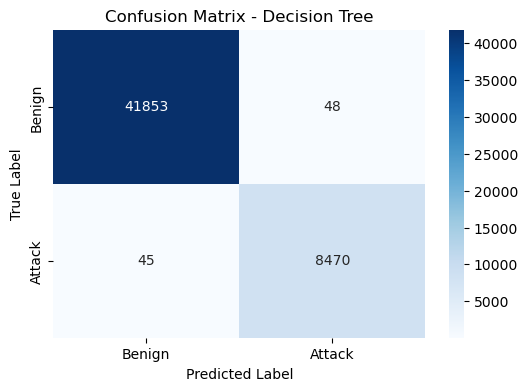

In [26]:
# Visualize Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Benign', 'Attack'], yticklabels=['Benign', 'Attack'])
plt.title('Confusion Matrix - Decision Tree')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()